In [18]:
import pandas as pd
import numpy as np
from scipy.stats import skewnorm
import seaborn as sns
from efficient_apriori import apriori
import re
import numpy as np
from scipy import stats
import statistics
from statistics import median

In [19]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
datas = pd.read_csv('NASACompositeDataset06122025.csv', comment='#', low_memory=False)
#These two were labeled incorrectly on the dataframe
datas.replace({ 'st_spectype': {'m3 V':'M V'} }, inplace = True)
datas.replace({ 'st_spectype': {'sdBV':'B V'} }, inplace = True)

In [20]:
def randomize_value(row, value_col, err1_col, err2_col):
    try:
        value = row[value_col]

        # Estimate mean from asymmetric errors
        mean = value + ((row[err1_col] + row[err2_col]) / 2)

        # Estimate symmetric standard deviation
        sd = value + row[err1_col] - mean

        # Skewness parameter
        a = (3 * (mean - value)) / sd

        return skewnorm.rvs(a,loc=mean,scale=row[err1_col],size=1)[0]
    
    except:
        return row[value_col]

#estimates the semimajor axis given a row of a data frame given stellar mass and orbital period: Kepler's 3rd law
#Only estimates the semimajor axis if the value is originally NaN
def estimate_orbsmax(row):
    if pd.isna(row['pl_orbsmax']):
        try: 
            #Units of
            P = row['pl_orbper'] / 365.25 # years
            M = row['st_mass'] # solar masses
            a_AU = (M * P**2)**(1/3) #AU
            return a_AU
        except:
            return np.nan
    else:
        return row['pl_orbsmax']
        

#Sets the spectral type if it is already in the string for the spectype variable for each row.
#Otherwise, it is estimated based on equillibrium temperature.
def get_spectype(row):
    try: 
        return row['st_spectype'][0]
    except:
        if(row['st_teff']>=30000):
            return 'O'
        elif(row['st_teff']>=10000):
            return 'B'
        elif(row['st_teff']>=7500):
            return 'A'
        elif(row['st_teff']>=6000):
            return 'F'
        elif(row['st_teff']>=5200):
            return 'G'
        elif(row['st_teff']>=3700):
            return 'K'
        elif(row['st_teff']>=2400):
            return 'M'
        else:
            return row['st_spectype']

#Estimates the equillibrium temperature of a row given stellar luminosity, and semimajor axis
#Only estimates if there is a missing value for pl_eqt: Stefan-Boltzmann's law
def estimate_pl_eqt(row):
    if pd.isna(row['pl_eqt']):
        try:
        # T = [L / (16pi sigma r**2)]**(.25)
            return (((10 ** row['st_lum']) * 3.827e26) / (16 * np.pi * 5.67e-8 * ((row['pl_orbsmax'] * 1.496e11) ** 2))) ** (1 / 4)
        except:
            return np.nan
    else:
        return row['pl_eqt']


#Grabs the last value of the string, usually the Luminosity Class of the data
#Otherwise, estimates whethoer or not the star is main sequence based on the luminosity of the star
def is_mainsequence(row):
    if(str(row['st_spectype'])[-1] == ('V') and str(row['st_spectype'])[-2:] != ('IV')):
        return 'True'
    else:
        try:
            if(str(row['spectype']).__contains__('M') and row['st_lum'] < -1.0969):
                return 'True'
            elif(str(row['spectype']).__contains__('K') and row['st_lum'] < -0.2218):
                return 'True'
            elif(str(row['spectype']).__contains__('G') and row['st_lum'] < 0.1761):
                return 'True'
            elif(str(row['spectype']).__contains__('F') and row['st_lum'] < 0.699):
                return 'True'
            elif(str(row['spectype']).__contains__('A') and row['st_lum'] < 1.3979):
                return 'True'
            elif(str(row['spectype']).__contains__('B') and row['st_lum'] < 4.477):
                return 'True'
            elif(str(row['spectype']).__contains__('O')):
                return 'True'
            else:
                return 'False'
        except:
            return 'False'   

#Gets the right hand and left hand side of the rule and puts it in an items list
pl_pattern = re.compile(r'(.+?)(\d)')
def parse_rule(rule_str):
    lhs, rhs = rule_str.split('->')
    lhs_items = [item.strip() for item in lhs.strip('{} ').split(',')]
    rhs = rhs.split("{")[1].split("}")[0]
    rhs_items = [item.strip() for item in rhs.strip('{} ').split(',')]
    return lhs_items, rhs_items

#Puts items in a system into a dictionary so that they are easy to compare, get counts for classifications
def get_plnum_dict(items):
    orbital_dict = {}
    for item in items:
        match = pl_pattern.match(item)
        if match:
            base_type, number = match.groups()
            number = int(number)
            orbital_dict.setdefault(base_type, set()).add(number)
    return orbital_dict

#randomize stellar properties.
def randomize_star_property(data, column, err1, err2):
    for host, group in data.groupby('hostname'):
        mean = None
        
        for index, row in group.iterrows():
            try:
                if mean is None:
                    mean = row[column] + ((row[err1] + row[err2]) / 2)
                    sd = row[column] + row[err1] - mean
                    a = 3 * (mean - row[column]) / sd
                    
                    value = skewnorm.rvs(a,loc=mean,scale=sd)[0]

                data.at[index, column] = value
                
            except:
                pass

    return data

In [31]:
data = datas.copy(deep= True)

#applying all of the non-random variables
data['pl_orbsmax'] = data.apply(estimate_orbsmax, axis=1)
data['pl_eqt'] = data.apply(estimate_pl_eqt, axis = 1)
data['spectype'] = data.apply(get_spectype, axis = 1)
data['isMS'] = data.apply(is_mainsequence, axis = 1)

#Remove systems with more that one host star
data = data.loc[data['sy_snum'] < 2]
# Excluded planet systems that did not have any data on the variables of interest
required = ['pl_orbper','pl_rade','st_teff','pl_eqt','spectype']
data = data.dropna(subset=required)

#Add labels (bins) to each characteristic range.
data['pl_rad_bin'] = pd.cut(data['pl_rade'], bins = [0, 1.7, 3.9, 9.4, 5000], labels = ['Terrestrial', 'Mini-Neptune', 'Sub-Saturn', 'Gas Giant'])
data['pl_orb_bin'] = pd.cut(data['pl_orbper'], bins = [0, 10, 100, 1000, 10000000000], labels = ['Short Orbital', 'Medium-Short Orbital', 'Medium-Long Orbital', 'Long Orbital'])
data['pl_eqt_bin'] = pd.cut(data['pl_eqt'], bins = [0, 200, 400, 1000, 10000000], labels = ['Cold', 'Temperate', 'Warm', 'Hot'])

#combine all of the planet characteristics into one trait
data['pl_class'] = data[['pl_eqt_bin','pl_rad_bin', 'pl_orb_bin']].astype('str').agg(" ".join, axis=1)

#combine all planet and star characteristics into one trait
data['stars_class'] = data[['spectype', 'pl_class']].agg(" ".join, axis=1)

#Creating a dataframe with only main sequence stars and their proper classificaiton
onlyMS = data.loc[data['isMS'] == 'True']

#originally 55 rules from only MS and pl class
test = {'type': onlyMS['pl_class'],'host':onlyMS['hostname']}

#originally 92 rules using only MS and pl+star class
'''test = {'type': onlyMS['stars_class'],'host':onlyMS['hostname']}'''

#originally 70 rules using all stars and pl class
'''test = {'type': data['pl_class'],'host':data['hostname']}'''

#Originally 103 rules using all stars and pl+st class
'''test = {'type': data['stars_class'],'host':data['hostname']}'''

testing = pd.DataFrame(data=test)
repeats = testing.groupby('host')

#Put into tuples by host star for the package
modified_tuples = []
for host, group in repeats:
    seen = {}
    new_types = []
    for t in group['type']:
        if t not in seen:
            seen[t] = 1
            new_types.append(f"{t}{seen[t]}")
        else:
            seen[t] += 1
            new_types.append(f"{t}{seen[t]}")
    modified_tuples.append(tuple(new_types))

#run the apriori algorith on the host tuples. The minimum support requires 2 of the same planet types throughout the dataset.
origitemset, origrules = apriori(modified_tuples, min_support= 2/len(modified_tuples), min_confidence= 0.5)

#Sometimes, with the numbering system (ex. pl_3 -> pl_1, pl_2 -> pl_1) there are repeat rules. We filter out repeats. 3 and 2 without 1. 
filtered_rules = []

#goes through every rule created using the cheat method and removes rules whose left side does not have sequential orders of planets: ex. 3 without 2 or 1
for rule in origrules:
    #get the rule as a string and seporate each planet to the left/right side with number
    rule_str = str(rule)
    lhs_items, rhs_items = parse_rule(rule_str)
    lhs_plnum = get_plnum_dict(lhs_items)
    rhs_plnum = get_plnum_dict(rhs_items)
    all_items = lhs_items + rhs_items
    all_plnum = get_plnum_dict(all_items)
    rule_valid = True
    for base_type, plnums in lhs_plnum.items():
        for num in plnums:
            if num > 1:
                required = set(range(1, num))
                if not required.issubset(plnums):
                    rule_valid = False
                    break
        if not rule_valid:
            break
    for base_type, plnum in rhs_plnum.items():
        if not rule_valid:
            break
        for items in plnum:
            if items > 1:
                required = set(range(1, items))
                if not required.issubset(all_plnum[base_type]):
                    rule_valid = False
                    break
    if rule_valid:
        filtered_rules.append(rule)

print('There are ' + str(len(filtered_rules))+ ' rules.')

There are 55 rules.


In [21]:
#number of fake universes 
univnum = 100

369
The median value is: 4


Text(0.5, 0, 'Rule percent success per transaction set')

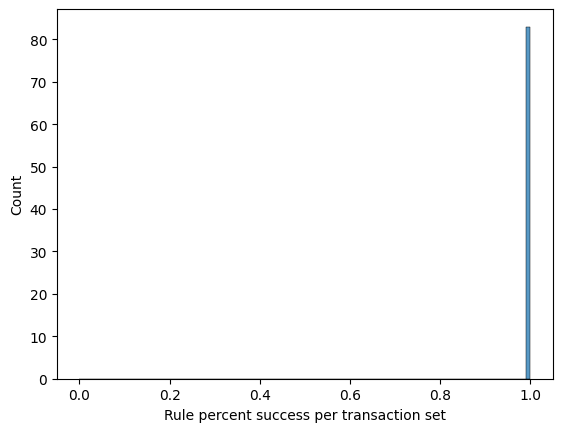

In [ ]:
#all the rules and their proportion of prevalence in all universes
#rule: number of universes where it appeared
ruledict = dict()

# creates univnum universes with randomly asisgned variables
for i in range(univnum):

    # don't reuse the same set over and over again: start new
    data = datas.copy(deep= True)

    sortbyhost = data.groupby('hostname')

    #randomize the stellar temp, luminosity, and mass.
    data = randomize_star_property(data,'st_teff','st_tefferr1','st_tefferr2')
    data = randomize_star_property(data,'st_lum','st_lumerr1','st_lumerr2')
    data = randomize_star_property(data,'st_mass','st_masserr1','st_masserr2')
    
    #applying all of the random variables
    data['pl_eqt'] = data.apply(randomize_value,axis=1,args=('pl_eqt', 'pl_eqterr1', 'pl_eqterr2'))
    data['pl_rade'] = data.apply(randomize_value,axis=1,args=('pl_rade', 'pl_radeerr1', 'pl_radeerr2'))
    data['pl_orbsmax'] = data.apply(randomize_value,axis=1,args=('pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2'))
    data['pl_orbper'] = data.apply(randomize_value,axis=1,args=('pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2'))
    data['pl_orbsmax'] = data.apply(estimate_orbsmax, axis=1)
    data['pl_eqt'] = data.apply(estimate_pl_eqt, axis = 1)
    data['spectype'] = data.apply(get_spectype, axis = 1)
    data['isMS'] = data.apply(is_mainsequence, axis = 1)

    #Remove systems with more that one host star
    data = data.loc[data['sy_snum'] < 2]
    # Excluded planet systems that did not have any data on the variables of interest
    required = ['pl_orbper','pl_rade','st_teff','pl_eqt','spectype']
    data = data.dropna(subset=required)
    
    #Grouping planets into their bins.
    data['pl_rad_bin'] = pd.cut(data['pl_rade'], bins = [0, 1.7, 3.9, 9.4, 5000], labels = ['Terrestrial', 'Mini-Neptune', 'Sub-Saturn', 'Gas Giant'])
    data['pl_orb_bin'] = pd.cut(data['pl_orbper'], bins = [0, 10, 100, 1000, 10000000000], labels = ['Short Orbital', 'Medium-Short Orbital', 'Medium-Long Orbital', 'Long Orbital'])
    data['pl_eqt_bin'] = pd.cut(data['pl_eqt'], bins = [0, 200, 400, 1000, 10000000], labels = ['Cold', 'Temperate', 'Warm', 'Hot'])
    data['pl_class'] = data[['pl_eqt_bin','pl_rad_bin', 'pl_orb_bin']].astype('str').agg(" ".join, axis=1)
    data['stars_class'] = data[['spectype', 'pl_class']].agg(" ".join, axis=1)
    #Creating a dataframe with only main sequence stars and their proper classificaiton
    onlyMS = data.loc[data['isMS'] == 'True']

    #only main sequence, planets
    test = {'type': onlyMS['pl_class'],'host':onlyMS['hostname']}

    #only main sequence, planets+ stars
    '''test = {'type': onlyMS['stars_class'],'host':onlyMS['hostname']}'''

    #all stars, planets
    '''test = {'type': data['pl_class'],'host':data['hostname']}'''

    #all stars, planets+ stars
    '''test = {'type': data['stars_class'],'host':data['hostname']}'''

    testing = pd.DataFrame(data=test)
    repeats = testing.groupby('host')

    modified_tuples = []
    for host, group in repeats:
        seen = {}
        new_types = []
        for t in group['type']:
            if t not in seen:
                seen[t] = 1
                new_types.append(f"{t}{seen[t]}")
            else:
                seen[t] += 1
                new_types.append(f"{t}{seen[t]}")
        modified_tuples.append(tuple(new_types))

    #run the apriori algorithm
    itemsetidk, repeatrules = apriori(modified_tuples, min_support= 2/len(modified_tuples), min_confidence=.5)


    filtered_rules = []

    #goes through every rule created using the cheat method and removes rules whose left side does not have sequential orders of planets: ex. 3 without 2 or 1
    for rule in repeatrules:
        rule_str = str(rule)
        lhs_items, rhs_items = parse_rule(rule_str)
        lhs_plnum = get_plnum_dict(lhs_items)
        rhs_plnum = get_plnum_dict(rhs_items)
        all_items = lhs_items + rhs_items
        all_plnum = get_plnum_dict(all_items)
        rule_valid = True
        for base_type, plnums in lhs_plnum.items():
            for num in plnums:
                if num > 1:
                    required = set(range(1, num))
                    if not required.issubset(plnums):
                        rule_valid = False
                        break
            if not rule_valid:
                break
        for base_type, plnum in rhs_plnum.items():
            if not rule_valid:
                break
            for items in plnum:
                if items > 1:
                    required = set(range(1, items))
                    if not required.issubset(all_plnum[base_type]):
                        rule_valid = False
                        break
        if rule_valid:
            filtered_rules.append(rule)
    for rule in filtered_rules:
        looper = 0
        for x in ruledict:
            if(rule == x):
                ruledict[x]+=1
                looper = 1
        if(looper == 0):
            ruledict[rule] = 1
if (i%20 == 0):
    print(i)

#convert to a proportion
sample_data = np.array(list(ruledict.values())) / univnum   

#output the number of unique rules for all simulations
print(ruledict.__len__())

The median value is: 0.04


Text(0, 0.5, 'Number of rules')

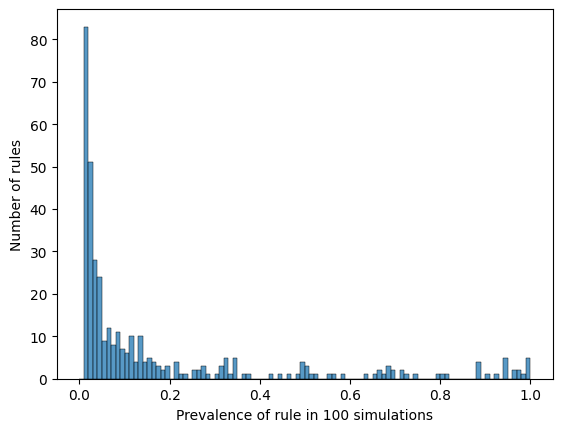

In [42]:
print("The median value is:", statistics.median(sample_data))
plot = sns.histplot(sample_data,bins=univnum,binrange=(0,1))
plot.set_xlabel('Prevalence of rule in 100 simulations')
plot.set_ylabel('Number of rules')

In [ ]:
#DO NOT USE. THIS IS FOR A T-TEST. IT DOES NOT WORK.

'''# number of rules that pass the t-test
count = 0

#name of rules that pass the test
listnew = []

for rule in ruledict:
    pop_mean_hypothesized = ruledict[rule]

    #This is testing whether the rule (pop_mean_hypothesized) appears significantly more than the other rules (sample_data).
    t_statistic, p_value_two_sided = stats.ttest_1samp(sample_data, pop_mean_hypothesized)

    if(t_statistic<0):
        pvalue = p_value_two_sided/2
    
    else:
        pvalue = 1-(p_value_two_sided/2)
    
    if(pvalue<=.05):
        #If it is significantly greater, then it passes
        count+=1
        listnew.append(rule)
print(count)
listnew'''

#DO NOT USE. THIS IS FOR A T-TEST. Independence???

In [39]:
mean = np.mean(sample_data)
print(f'the mean is {mean}')
std = np.std(sample_data)
print(f'the sd is {std}')

#rules that appear 3 standard deviations more than other rules, on average
common_rules = []

for rule, prevalence in ruledict.items():
    if prevalence/100 > mean + 2*std:
        common_rules.append(rule)

print(f'num of common rules: {len(common_rules)} total num of rules: {len(sample_data)}; {len(common_rules)/ len(sample_data)}')

the mean is 0.16991869918699187
the sd is 0.25938063376700976
num of common rules: 32 total num of rules: 369; 0.08672086720867209


In [40]:
#number of common rules between the median value universe and the significant rules from 100 universes.
shared_rule_list = list(set(filtered_rules) & set(common_rules))
print(len(shared_rule_list))

29


In [ ]:
data = datas.copy(deep= True)
#applying all of the non-random variables
data['pl_orbsmax'] = data.apply(estimate_orbsmax, axis=1)
data['pl_eqt'] = data.apply(estimate_pl_eqt, axis = 1)
data['spectype'] = data.apply(get_spectype, axis = 1)
data['isMS'] = data.apply(is_mainsequence, axis = 1)
#Remove systems with more that one host star
data = data.loc[data['sy_snum'] < 2]
# Excluded planet systems that did not have any data on the variables of interest
required = ['pl_orbper','pl_rade','st_teff','pl_eqt','spectype']
data = data.dropna(subset=required)
data['pl_rad_bin'] = pd.cut(data['pl_rade'], bins = [0, 1.7, 3.9, 9.4, 5000], labels = ['Terrestrial', 'Mini-Neptune', 'Sub-Saturn', 'Gas Giant'])
data['pl_orb_bin'] = pd.cut(data['pl_orbper'], bins = [0, 10, 100, 1000, 10000000000], labels = ['Short Orbital', 'Medium-Short Orbital', 'Medium-Long Orbital', 'Long Orbital'])
data['pl_eqt_bin'] = pd.cut(data['pl_eqt'], bins = [0, 200, 400, 1000, 10000000], labels = ['Cold', 'Temperate', 'Warm', 'Hot'])
data['pl_class'] = data[['pl_eqt_bin','pl_rad_bin', 'pl_orb_bin']].astype('str').agg(" ".join, axis=1)
data['stars_class'] = data[['spectype', 'pl_class']].agg(" ".join, axis=1)
#Creating a dataframe with only main sequence stars and their proper classificaiton
onlyMS = data.loc[data['isMS'] == 'True']

#originally 55 only MS and pl class
test = {'type': onlyMS['pl_class'],'host':onlyMS['hostname']}

#originally 92 only MS and pl+star class
'''test = {'type': onlyMS['stars_class'],'host':onlyMS['hostname']}'''

#originally 70 all stars and pl class
'''test = {'type': data['pl_class'],'host':data['hostname']}'''

#Originally 103 all stars and pl+st class
'''test = {'type': data['stars_class'],'host':data['hostname']}'''

testing = pd.DataFrame(data=test)
repeats = testing.groupby('host')

#Put into tuples by host star for the package
modified_tuples = []
for host, group in repeats:
    seen = {}
    new_types = []
    for t in group['type']:
        if t not in seen:
            seen[t] = 1
            new_types.append(f"{t}{seen[t]}")
        else:
            seen[t] += 1
            new_types.append(f"{t}{seen[t]}")
    modified_tuples.append(tuple(new_types))

origitemset, origrules = apriori(modified_tuples, min_support= 2/len(modified_tuples), min_confidence=.5)

mediandict = {}
#lhsdict = {}
for rule in origrules:
    rule_str = str(rule)
    lhs_items, rhs_items = parse_rule(rule_str)
    '''if(lhsdict.__contains__(str(lhs_items))):
        lhsdict[str(lhs_items)] = lhsdict[str(lhs_items)]+1
    else:
        lhsdict[str(lhs_items)] = 1'''
    mediandict[str(rhs_items)] = (lhs_items, rule.lift)



*** resilience do not use

In [ ]:
#number of fake universes 
univnum = 2

In [ ]:
#all the rules and their proportion of prevalence in all universes
ruledict = dict()
resilience_list = {}
# creates univnum universes with randomly asisgned variables
for i in range(univnum):
    # don't reuse the same set over and over again: start new
    data = datas.copy(deep= True)

    #assigns random stellar temperature
    sortbyhost = data.groupby('hostname')
    for host, group in sortbyhost:
        count = 0
        number = 0
        for index, row in group.iterrows():
            try:
                if count == 0:
                    mean = row['st_teff'] + ((row['st_tefferr1'] + row['st_tefferr2']) / 2)
                    sd = row['st_teff'] + row['st_tefferr1'] - mean
                    a = (3 * (mean - row['st_teff'])) / sd
                    number = skewnorm.rvs(a, loc=mean, scale=sd, size=1)[0]
                    count += 1
                data.at[index, 'st_teff'] = number
            except Exception as e:
                data.at[index, 'st_teff'] = row['st_teff']

    #assigns random stellar luminosity
    for host, group in sortbyhost:
        count = 0
        number = 0
        for index, row in group.iterrows():
            try:
                if count == 0:
                    mean = row['st_lum'] + ((row['st_lumerr1'] + row['st_lumerr2']) / 2)
                    sd = row['st_lum'] + row['st_lumerr1'] - mean
                    a = (3 * (mean - row['st_lum'])) / sd
                    number = skewnorm.rvs(a, loc=mean, scale=sd, size=1)[0]
                    count += 1
                data.at[index, 'st_lum'] = number
            except Exception as e:
                data.at[index, 'st_lum'] = row['st_lum']
    #assigns random stellar mass
    for host, group in sortbyhost:
        count = 0
        number = 0
        for index, row in group.iterrows():
            try:
                if count == 0:
                    mean = row['st_mass'] + ((row['st_masserr1'] + row['st_masserr2']) / 2)
                    sd = row['st_mass'] + row['st_masserr1'] - mean
                    a = (3 * (mean - row['st_mass'])) / sd
                    number = skewnorm.rvs(a, loc=mean, scale=sd, size=1)[0]
                    count += 1
                data.at[index, 'st_mass'] = number
            except Exception as e:
                data.at[index, 'st_mass'] = row['st_mass']
    
    #applying all of the random variables
    data['pl_rade'] = data.apply(rand_prade, axis = 1)
    data['pl_orbper'] = data.apply(rand_orbper, axis = 1)
    data['pl_eqt'] = data.apply(rand_temp, axis = 1)
    data['pl_orbsmax'] = data.apply(rand_majoraxis, axis = 1)
    data['pl_orbsmax'] = data.apply(estimate_orbsmax, axis=1)
    data['pl_eqt'] = data.apply(estimate_pl_eqt, axis = 1)
    data['spectype'] = data.apply(get_spectype, axis = 1)
    data['isMS'] = data.apply(is_mainsequence, axis = 1)

    #Remove systems with more that one host star
    star = data.loc[data['sy_snum'] == 1]
    # Excluded planet systems that did not have any data on the variables of interest
    star = star.loc[star['pl_orbper'].isna() == False]
    star = star.loc[star['pl_rade'].isna() == False]
    star = star.loc[star['st_teff'].isna() == False]
    star = star.loc[star['pl_eqt'].isna() == False]
    star = star.loc[star['spectype'].isna() == False]
    #Grouping planets into their bins.
    star['pl_rad_bin'] = pd.cut(star['pl_rade'], bins = [0, 1.7, 3.9, 9.4, 5000], labels = ['Terrestrial', 'Mini-Neptune', 'Sub-Saturn', 'Gas Giant'])
    star['pl_orb_bin'] = pd.cut(star['pl_orbper'], bins = [0, 10, 100, 1000, 10000000000], labels = ['Short Orbital', 'Medium-Short Orbital', 'Medium-Long Orbital', 'Long Orbital'])
    star['pl_eqt_bin'] = pd.cut(star['pl_eqt'], bins = [0, 200, 400, 1000, 10000000], labels = ['Cold', 'Temperate', 'Warm', 'Hot'])
    star['pl_class'] = star[['pl_eqt_bin','pl_rad_bin', 'pl_orb_bin']].astype('str').agg(" ".join, axis=1)
    star['stars_class'] = star[['spectype', 'pl_class']].agg(" ".join, axis=1)
    #Creating a dataframe with only main sequence stars and their proper classificaiton
    onlyMS = star.loc[star['isMS'] == 'True']

    #only main sequence, planets
    test = {'type': onlyMS['pl_class'],'host':onlyMS['hostname']}

    #only main sequence, planets+ stars
    '''test = {'type': onlyMS['stars_class'],'host':onlyMS['hostname']}'''

    #all stars, planets
    '''test = {'type': star['pl_class'],'host':star['hostname']}'''

    #all stars, planets+ stars
    '''test = {'type': star['stars_class'],'host':star['hostname']}'''

    testing = pd.DataFrame(data=test)
    repeats = testing.groupby('host')

    #repeats = testingMSpl.groupby('host')
    modified_tuples = []
    for host, group in repeats:
        seen = {}
        new_types = []
        for t in group['type']:
            if t not in seen:
                seen[t] = 1
                new_types.append(f"{t}{seen[t]}")
            else:
                seen[t] += 1
                new_types.append(f"{t}{seen[t]}")
        modified_tuples.append(tuple(new_types))
    newitemset, newrules = apriori(modified_tuples, min_support= 2/len(modified_tuples), min_confidence=.5)
    resilience = {}
    resi = []
    for rule in newrules:
        rule_str = str(rule)
        lhs_items, rhs_items = parse_rule(rule_str)
        for entries in mediandict:
            if(str(rhs_items) == entries):
                for itemn in lhs_items:
                    if ((mediandict[entries])[0].__contains__(itemn)):
                        union = 0
                        for left in lhs_items:
                            for lefts in (mediandict[entries])[0]:
                                if(left == lefts):
                                    union+=1
                        resil = ((len((mediandict[entries])[0])/len(lhs_items))*abs((mediandict[entries])[1] - rule.lift)*(1/union))
                        if str(rhs_items) in resilience:
                            resilience[str(rhs_items)].append((mediandict[entries][0], lhs_items, resil))
                        else:
                            resilience[str(rhs_items)] = [(mediandict[entries][0], lhs_items, resil)]
                        resi.append(resil)
                        break
    resilience_list[str(i)] = resilience
print('Q1 =', np.percentile(resi, 25))
print('median = ', statistics.median(resi))
print('Q3 =', np.percentile(resi, 75))

resilplot = sns.histplot(x = resi, bins= 1000)
resilplot.set(xlim=(-1, 100), xlabel= 'resilience')

In [ ]:
'''print((mediandict[entries])[1])
print(rule.lift)'''
resilience_list